# Plot

In [1]:
import numpy as np
import scipy.linalg
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar
from scipy.optimize import curve_fit
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.colorbar as colorbars
import matplotlib.gridspec as gridspec
#import pandas as pd
import datetime
import os
import time
import pathlib
import pickle
import sys
import string
#import uncertainties
#from uncertainties import ufloat

import ising_model as ising

plt.rcParams["font.family"] = "Helvetica"
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['svg.fonttype'] = 'path'

cm = plt.get_cmap('Paired')
blue = cm(1)
green = cm(3)
red = cm(5)
orange = cm(7)
purple = cm(9)

## Load data

In [2]:
# instance
n_spin_list = [5,10,15,20,25]
n_train_list = [5,10,15,20,25,30,40,50,100,200,500,1000,5000,10000]
 
# import data
opt_mcmc_data, fix_mcmc_data = {}, {}
for i in range(len(n_spin_list)):
	for j in range(len(n_train_list)):
		opt_mcmc_data[(n_spin_list[i], n_train_list[j])] = np.load("result/vs_train_data/{0}_sites_result/{1}_samples/opt_qaoa_made_result.npy".format(n_spin_list[i], n_train_list[j]))
		fix_mcmc_data[(n_spin_list[i], n_train_list[j])] = np.load("result/vs_train_data/{0}_sites_result/{1}_samples/fix_qaoa_made_result.npy".format(n_spin_list[i], n_train_list[j]))

## Autocorrelation

In [3]:
def mcmc_magnetization_autocorrelation(spin_history, lag):
	mag_history = np.average(spin_history, axis=2)
	mag_mean = np.tile(np.average(mag_history, axis=1).reshape((mag_history.shape[0],1)), (1,spin_history.shape[1]))
	mag_acf = np.zeros((spin_history.shape[0], lag))
    
	for j in range(lag):
		if j == 0:
			mag_acf[:,j] = 1.0
		else:
			n = spin_history.shape[1] - j
			mag_acf[:,j] = np.average((mag_history[:,:n] - mag_mean[:,:n]) * (mag_history[:,-n:] - mag_mean[:,:n]), axis=1)
			mag_acf[:,j] /= np.sqrt(np.average((mag_history[:,:n] - mag_mean[:,:n])**2, axis=1) * np.average((mag_history[:,-n:] - mag_mean[:,:n])**2, axis=1))
	
	return mag_acf

def exp_func(x,a):
    return np.exp(-1.0 * (x/a))

def acf_exp_fitting(acf):
	negative_idx = np.argmax(acf < 0, axis=1)
	negative_idx[negative_idx==0] = acf.shape[1] - 1

	exp_fit_popt = np.zeros(acf.shape[0])

	for i in range(acf.shape[0]):
		popt = curve_fit(f=exp_func, xdata=np.arange(negative_idx[i]+1), ydata=acf[i,0:negative_idx[i]], maxfev=10000)[0]
		exp_fit_popt[i] = popt[0]

	return exp_fit_popt

def compute_iat(acf):
	negative_idx = np.argmax(acf < 0, axis=1)
	negative_idx[negative_idx==0] = acf.shape[1] - 1

	iat = np.zeros(acf.shape[0])
	for i in range(acf.shape[0]):
		iat[i] = 1.0 + 2.0 * np.sum(acf[i,1:negative_idx[i]])
	return iat

def exp_func_2(x,a,b,c):
    return c + b * np.exp(-a*x)

# magnetization autocorrelation
lag = 1000
opt_list = np.zeros((len(n_spin_list), len(n_train_list), 2))
fix_list = np.zeros((len(n_spin_list), len(n_train_list), 2))

opt_fit = np.empty(shape=(len(n_spin_list),3))
fix_fit = np.empty(shape=(len(n_spin_list),3))

"""
for i in range(len(n_spin_list)):
	for j in range(len(n_train_list)):
		mag_acf_history_opt_made = mcmc_magnetization_autocorrelation(opt_mcmc_data[(n_spin_list[i],n_train_list[j])], lag)
		mag_acf_history_fix_made = mcmc_magnetization_autocorrelation(fix_mcmc_data[(n_spin_list[i],n_train_list[j])], lag)

		mag_acf_opt_made_ave = np.average(np.abs(mag_acf_history_opt_made[1:]), axis=0)
		mag_acf_opt_made_std = np.std(np.abs(mag_acf_history_opt_made[1:]), axis=0)

		mag_acf_fix_made_ave = np.average(np.abs(mag_acf_history_fix_made[1:]), axis=0)
		mag_acf_fix_made_std = np.std(np.abs(mag_acf_history_opt_made[1:]), axis=0)

		opt_popt, opt_pcov = curve_fit(exp_func, np.arange(lag), mag_acf_opt_made_ave[0:lag])
		fix_popt, fix_pcov = curve_fit(exp_func, np.arange(lag), mag_acf_fix_made_ave[0:lag])

		opt_list[i,j,0], opt_list[i,j,1] = opt_popt, opt_pcov
		fix_list[i,j,0], fix_list[i,j,1] = fix_popt, fix_pcov
  
	opt_fit[i,0], opt_fit[i,1], opt_fit[i,2] = curve_fit(exp_func_2, n_train_list, opt_list[i,:,0], p0=[0.1, opt_list[i,0,0], opt_list[i,-1,0]], bounds=(0,np.inf), maxfev=2000)[0]
	fix_fit[i,0], fix_fit[i,1], fix_fit[i,2] = curve_fit(exp_func_2, n_train_list, fix_list[i,:,0], p0=[0.1, fix_list[i,0,0], fix_list[i,-1,0]], bounds=(0,np.inf), maxfev=2000)[0]
"""
burn_in = 0
for i in range(len(n_spin_list)):
	for j in range(len(n_train_list)):
		mag_acf_history_opt_made = mcmc_magnetization_autocorrelation(opt_mcmc_data[(n_spin_list[i],n_train_list[j])][:,burn_in:], lag)
		mag_acf_history_fix_made = mcmc_magnetization_autocorrelation(fix_mcmc_data[(n_spin_list[i],n_train_list[j])][:,burn_in:], lag)

		#opt_popt = acf_exp_fitting(mag_acf_history_opt_made)
		#fix_popt = acf_exp_fitting(mag_acf_history_fix_made)

		opt_popt = compute_iat(mag_acf_history_opt_made)
		fix_popt = compute_iat(mag_acf_history_fix_made)

		opt_list[i,j,0], opt_list[i,j,1] = np.average(opt_popt), np.std(opt_popt)
		fix_list[i,j,0], fix_list[i,j,1] = np.average(fix_popt), np.std(fix_popt)
  
	#opt_fit[i,0], opt_fit[i,1], opt_fit[i,2] = curve_fit(exp_func_2, n_train_list, opt_list[i,:,0], bounds=(0,np.inf), maxfev=2000)[0]
	#fix_fit[i,0], fix_fit[i,1], fix_fit[i,2] = curve_fit(exp_func_2, n_train_list, fix_list[i,:,0], bounds=(0,np.inf), maxfev=2000)[0]

## Plot

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


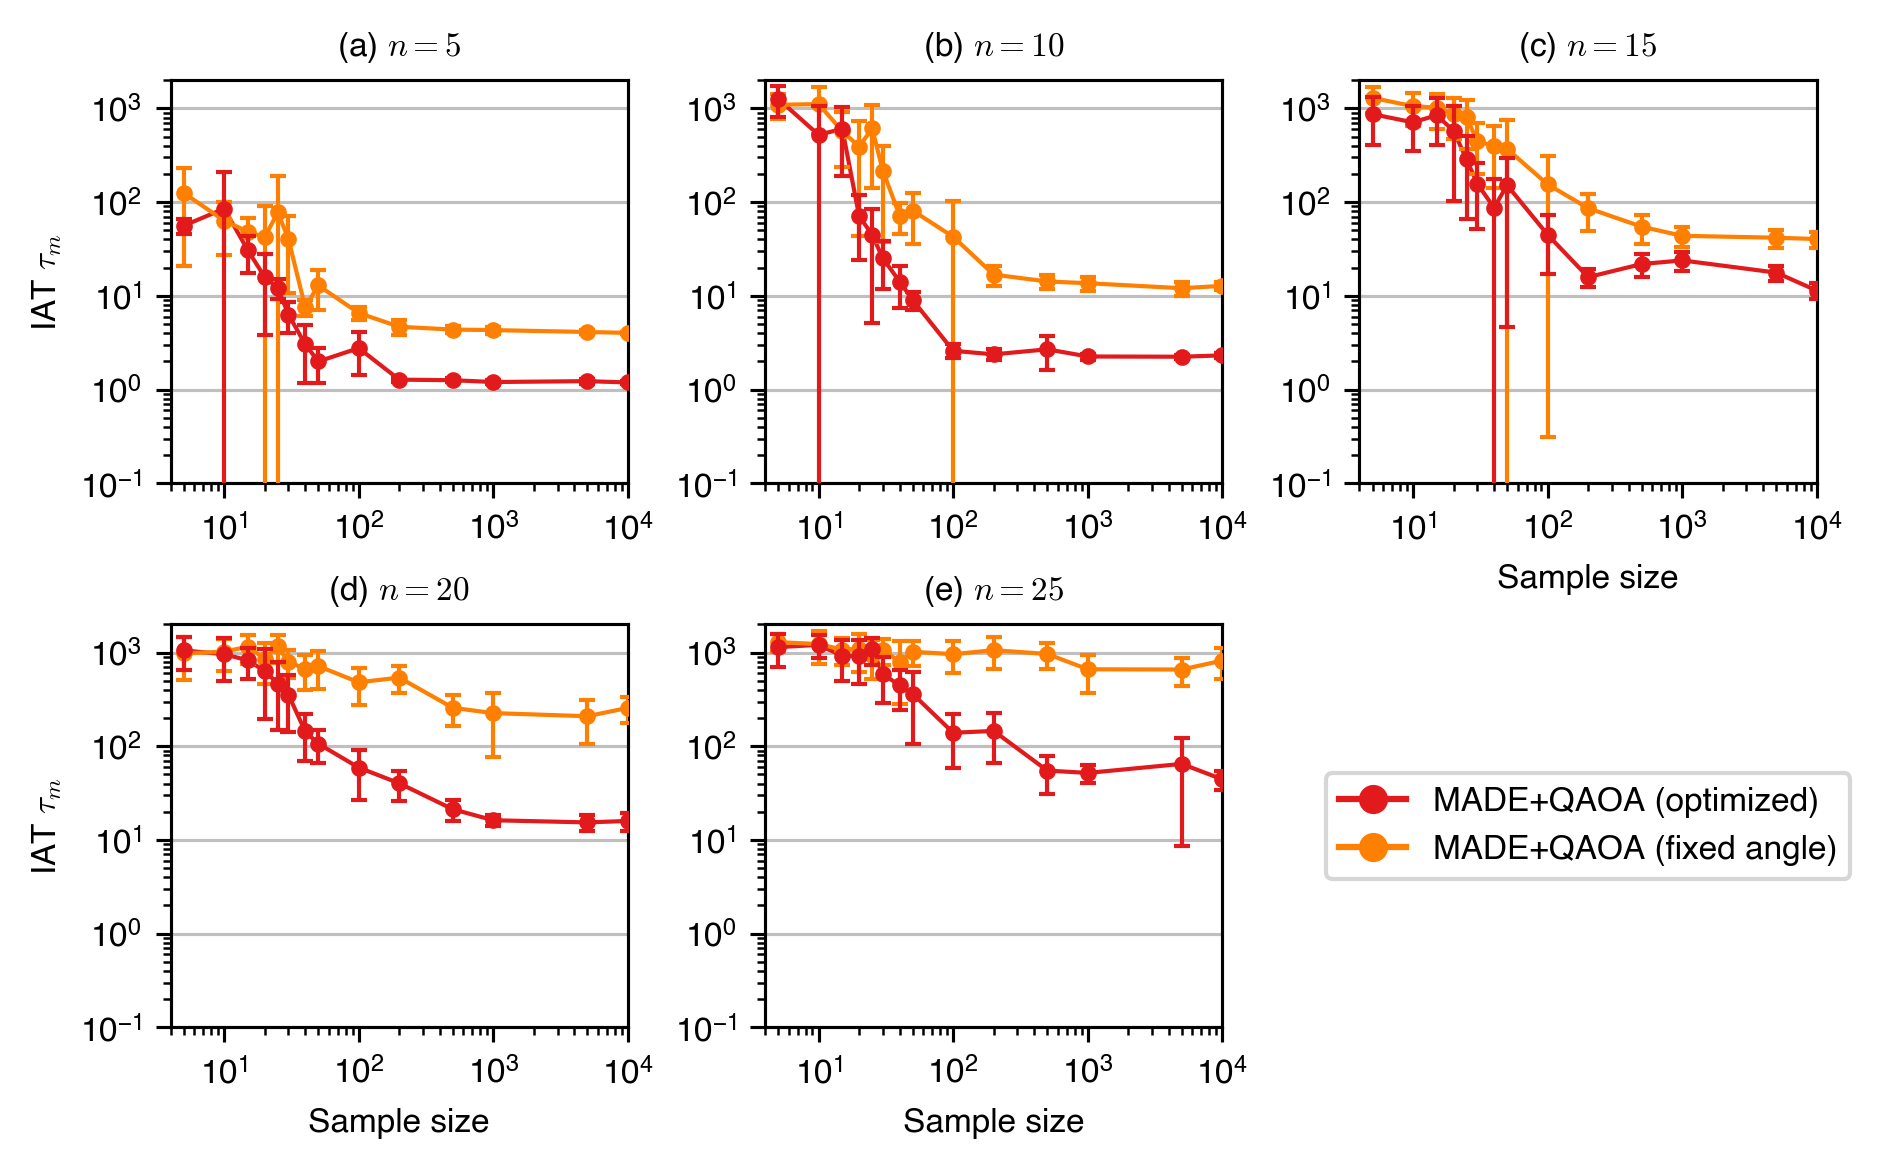

In [4]:
n_row = 2
n_col = 3

capsize = 2
markersize = 3
elinewidth = 1
capthick = 1
linewidth = 1
spines = 0.75
fontsize = 8

num_list = list(string.ascii_lowercase)[0:5]

fig1, ax1 = plt.subplots(n_row, n_col, figsize=(7.08, 4.1), gridspec_kw=dict(wspace=0.3, hspace=0.35), dpi=300)

for i in range(len(n_spin_list)):
	row = i // n_col
	col = i % n_col

	ax1[row,col].errorbar(n_train_list, opt_list[i,:,0], opt_list[i,:,1], color=red, linestyle='none', marker='o', markersize=markersize, capsize=capsize, capthick=capthick, elinewidth=elinewidth, label='MADE+QAOA (optimized)', zorder=5)
	ax1[row,col].errorbar(n_train_list, fix_list[i,:,0], fix_list[i,:,1], color=orange, linestyle='none', marker='o', markersize=markersize, capsize=capsize, capthick=capthick, elinewidth=elinewidth, label='MADE+QAOA (fixed angle)', zorder=4)
	ax1[row,col].plot(n_train_list, opt_list[i,:,0], color=red, linewidth=linewidth)
	ax1[row,col].plot(n_train_list, fix_list[i,:,0], color=orange, linewidth=linewidth)
	#ax1[row,col].plot(np.arange(n_train_list[-1]), exp_func_2(np.arange(n_train_list[-1]), *opt_fit[i]), color=red, linewidth=linewidth)
	#ax1[row,col].plot(np.arange(n_train_list[-1]), exp_func_2(np.arange(n_train_list[-1]), *fix_fit[i]), color=orange, linewidth=linewidth)
	ax1[row,col].grid(axis='y', color='#BFBFBF', linestyle='-', linewidth=spines)
 
	ax1[row,col].set_axisbelow(True) #gridを背面にする

	ax1[row,col].spines["top"].set_linewidth(spines)
	ax1[row,col].spines["left"].set_linewidth(spines)
	ax1[row,col].spines["bottom"].set_linewidth(spines)
	ax1[row,col].spines["right"].set_linewidth(spines)
	
	ax1[row,col].set_xscale("log")
	ax1[row,col].set_yscale("log")
	ax1[row,col].set_xlim(4, 1e4)
	ax1[row,col].set_ylim(1e-1, 2e3)
	#ax1[row,col].minorticks_off()
	ax1[row,col].set_title(r'({1}) $n={0}$'.format(n_spin_list[i],num_list[i]),{"fontsize": fontsize})
	ax1[row,col].tick_params(width=spines, labelsize=fontsize)
	#if col != 0:
		#ax1[row, col].tick_params(labelleft=False)

ax1[1,0].set_xlabel(r'Sample size', fontsize=fontsize)
ax1[1,1].set_xlabel(r'Sample size', fontsize=fontsize)
ax1[0,2].set_xlabel(r'Sample size', fontsize=fontsize)
ax1[0,0].set_ylabel(r'IAT $\tau_m$', fontsize=fontsize)
ax1[1,0].set_ylabel(r'IAT $\tau_m$', fontsize=fontsize)
  
ax1[-1,-1].plot([], [], marker='o', color=red, label='MADE+QAOA (optimized)', linestyle=None)
ax1[-1,-1].plot([], [], marker='o', color=orange, label='MADE+QAOA (fixed angle)', linestyle=None)

for spine in ax1[-1,-1].spines.values():
    spine.set_visible(False)
ax1[-1,-1].axes.get_xaxis().set_visible(False)
ax1[-1,-1].axes.get_yaxis().set_visible(False)

ax1[-1,-1].legend(fontsize=fontsize, bbox_to_anchor=(0.5,0.5), loc='center', frameon=True)

#fig1.savefig("figure/convergence_vs_training_data_size.svg", dpi=300, bbox_inches='tight')
print(opt_fit)

/var/folders/5z/hnd7blsn33vdfn4r3xgj5_sh0000gn/T/ipykernel_22597/3985679968.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_1_2 = matplotlib.cm.get_cmap('cool')


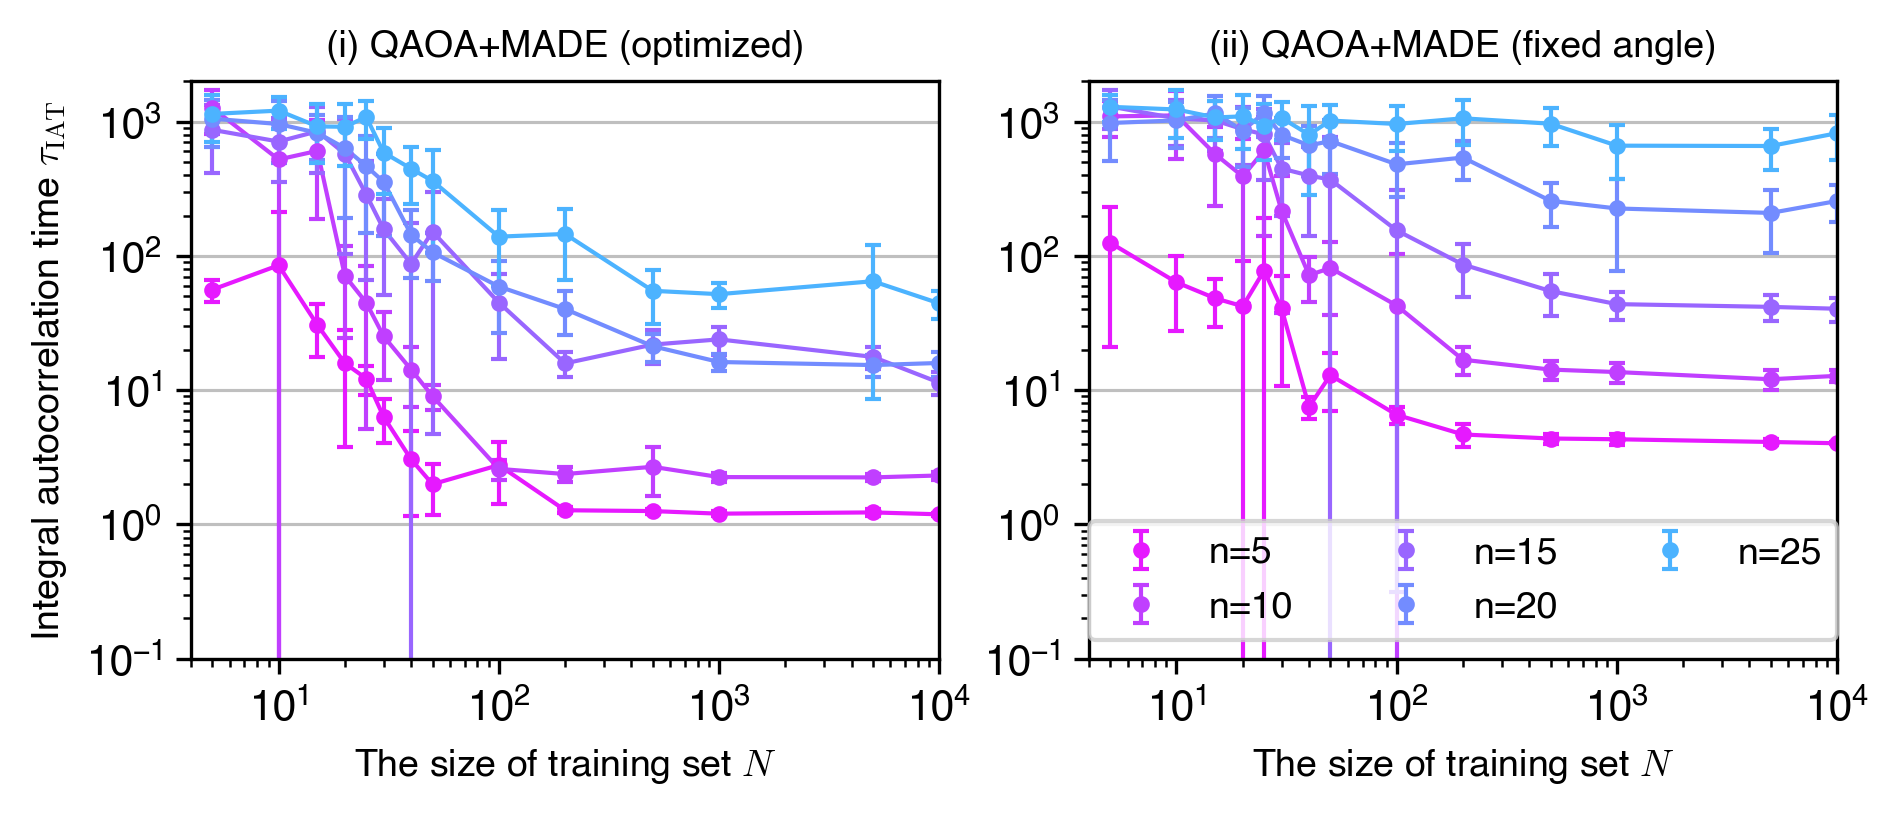

In [9]:
capsize = 2
markersize = 3
elinewidth = 1
capthick = 1
linewidth = 1
spines = 0.75
fontsize = 9

cmap_1_2 = matplotlib.cm.get_cmap('cool')

fig1_2, ax1_2 = plt.subplots(1, 2, figsize=(7.08,2.5), dpi=300)
for i in range(len(n_spin_list)):
	ax1_2[0].errorbar(n_train_list, opt_list[i,:,0], opt_list[i,:,1], color=cmap_1_2(0.9-0.15*i), linestyle='none', marker='o', markersize=markersize, capsize=capsize, capthick=capthick, elinewidth=elinewidth, label='n={0}'.format(n_spin_list[i]))
	ax1_2[0].plot(n_train_list, opt_list[i,:,0], color=cmap_1_2(0.9-0.15*i), linewidth=linewidth)
for i in range(len(n_spin_list)):
	ax1_2[1].errorbar(n_train_list, fix_list[i,:,0], fix_list[i,:,1], color=cmap_1_2(0.9-0.15*i), linestyle='none', marker='o', markersize=markersize, capsize=capsize, capthick=capthick, elinewidth=elinewidth, label='n={0}'.format(n_spin_list[i]))
	ax1_2[1].plot(n_train_list, fix_list[i,:,0], color=cmap_1_2(0.9-0.15*i), linewidth=linewidth)

for i in range(2):
	ax1_2[i].grid(axis='y', color='#BFBFBF', linestyle='-', linewidth=spines)
	ax1_2[i].set_axisbelow(True) #gridを背面にする
	ax1_2[i].set_xscale('log')
	ax1_2[i].set_yscale('log')
	ax1_2[i].set_xlim(4, 1e4)
	ax1_2[i].set_ylim(1e-1, 2e3)
	ax1_2[i].set_xlabel(r'The size of training set $N$', fontsize=fontsize)
	
ax1_2[0].set_ylabel(r'Integral autocorrelation time $\tau_{\rm{IAT}}$', fontsize=fontsize)
ax1_2[0].set_title(r'(i) QAOA+MADE (optimized)', fontsize=fontsize)
ax1_2[1].set_title(r'(ii) QAOA+MADE (fixed angle)', fontsize=fontsize)
ax1_2[1].legend(fontsize=fontsize, loc='lower center', ncol=3, frameon=True)

fig1_2.savefig("figure/convergence_vs_training_data_size.svg", dpi=300, bbox_inches='tight')

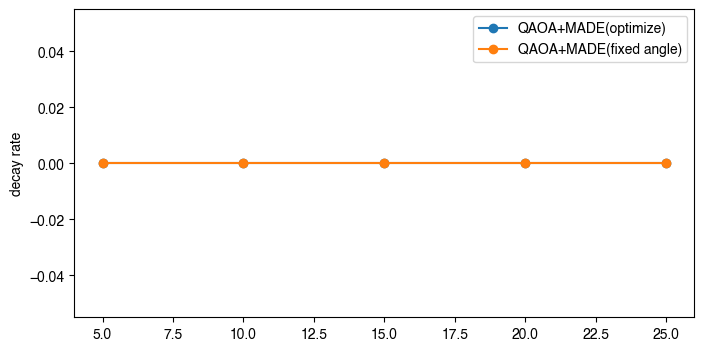

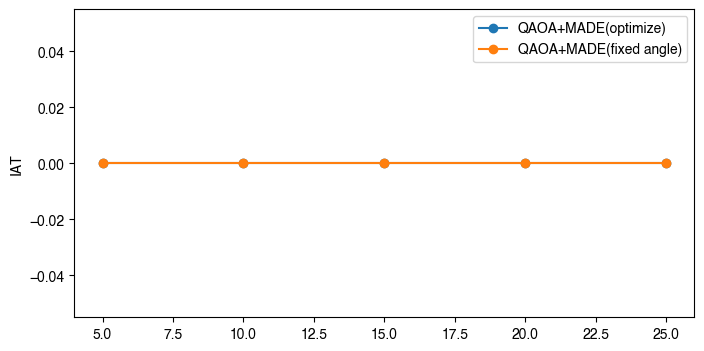

In [6]:
fig2, ax2 = plt.subplots(figsize=(8,4))
ax2.plot(n_spin_list, opt_fit[:,0], marker='o', label='QAOA+MADE(optimize)')
ax2.plot(n_spin_list, fix_fit[:,0], marker='o', label='QAOA+MADE(fixed angle)')
ax2.set_ylabel('decay rate')
ax2.legend()

fig2_1, ax2_1 = plt.subplots(figsize=(8,4))
ax2_1.plot(n_spin_list, opt_fit[:,2], marker='o', label='QAOA+MADE(optimize)')
ax2_1.plot(n_spin_list, fix_fit[:,2], marker='o', label='QAOA+MADE(fixed angle)')
ax2_1.set_ylabel('IAT')
ax2_1.legend()

## Acceptance rate vs train data

In [7]:
# import data
opt_mcmc_acceptance_history, fix_mcmc_acceptance_history = {}, {}
for i in range(len(n_spin_list)):
	for j in range(len(n_train_list)):
		opt_mcmc_acceptance_history[(n_spin_list[i], n_train_list[j])] = np.load("result/vs_train_data/{0}_sites_result/{1}_samples/opt_qaoa_made_acceptance_history.npy".format(n_spin_list[i], n_train_list[j]))
		fix_mcmc_acceptance_history[(n_spin_list[i], n_train_list[j])] = np.load("result/vs_train_data/{0}_sites_result/{1}_samples/fix_qaoa_made_acceptance_history.npy".format(n_spin_list[i], n_train_list[j]))
 
# acceptance rate
opt_mcmc_acceptance_rate, fix_mcmc_acceptance_rate = np.zeros((len(n_spin_list), len(n_train_list),10)), np.zeros((len(n_spin_list), len(n_train_list),10)) 
for i in range(len(n_spin_list)):
	for j in range(len(n_train_list)):
		opt_mcmc_acceptance_rate[i,j] = np.average(opt_mcmc_acceptance_history[(n_spin_list[i], n_train_list[j])], axis=1)
		fix_mcmc_acceptance_rate[i,j] = np.average(fix_mcmc_acceptance_history[(n_spin_list[i], n_train_list[j])], axis=1)
    
opt_mcmc_acceptance_mean, fix_mcmc_acceptance_mean = np.average(opt_mcmc_acceptance_rate, axis=2), np.average(fix_mcmc_acceptance_rate, axis=2)
opt_mcmc_acceptance_std, fix_mcmc_acceptance_std = np.std(opt_mcmc_acceptance_rate, axis=2), np.std(fix_mcmc_acceptance_rate, axis=2)
print(opt_mcmc_acceptance_mean.shape)

(5, 14)


/var/folders/5z/hnd7blsn33vdfn4r3xgj5_sh0000gn/T/ipykernel_22597/1791480619.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_3_0 = matplotlib.cm.get_cmap('cool')
/var/folders/5z/hnd7blsn33vdfn4r3xgj5_sh0000gn/T/ipykernel_22597/1791480619.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_3_1 = matplotlib.cm.get_cmap('cool')


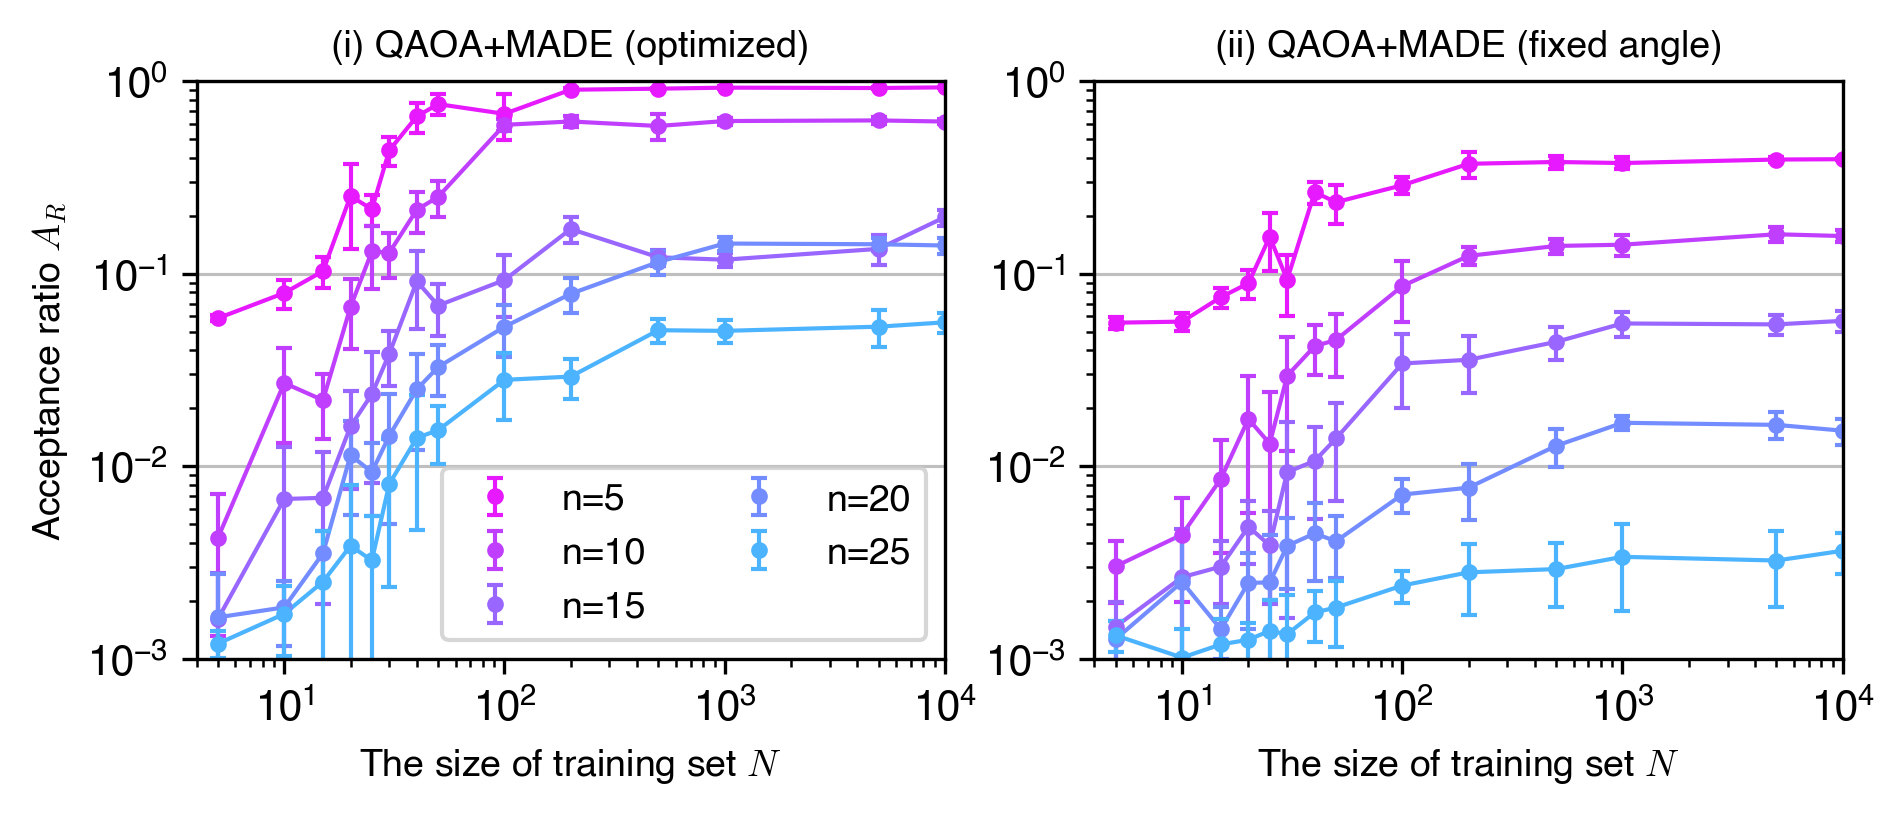

In [8]:
capsize = 2
markersize = 3
elinewidth = 1
capthick = 1
linewidth = 1
spines = 0.75
fontsize = 9

cmap_3_0 = matplotlib.cm.get_cmap('cool')
cmap_3_1 = matplotlib.cm.get_cmap('cool')

fig3, ax3 = plt.subplots(1, 2, figsize=(7.08,2.5), dpi=300)
for i in range(len(n_spin_list)):
	ax3[0].errorbar(n_train_list, opt_mcmc_acceptance_mean[i], opt_mcmc_acceptance_std[i], color=cmap_3_0(0.9-0.15*i), linestyle='none', marker='o', markersize=markersize, capsize=capsize, capthick=capthick, elinewidth=elinewidth, label='n={0}'.format(n_spin_list[i]))
	ax3[0].plot(n_train_list, opt_mcmc_acceptance_mean[i], color=cmap_3_0(0.9-0.15*i), linewidth=linewidth)
for i in range(len(n_spin_list)):
	ax3[1].errorbar(n_train_list, fix_mcmc_acceptance_mean[i], fix_mcmc_acceptance_std[i], color=cmap_3_1(0.9-0.15*i), linestyle='none', marker='o', markersize=markersize, capsize=capsize, capthick=capthick, elinewidth=elinewidth, label='n={0}'.format(n_spin_list[i]))
	ax3[1].plot(n_train_list, fix_mcmc_acceptance_mean[i], color=cmap_3_1(0.9-0.15*i), linewidth=linewidth)

for i in range(2):
	ax3[i].grid(axis='y', color='#BFBFBF', linestyle='-', linewidth=spines)
	ax3[i].set_axisbelow(True) #gridを背面にする
	ax3[i].set_xscale('log')
	ax3[i].set_yscale('log')
	ax3[i].set_xlim(4, 1e4)
	ax3[i].set_ylim(1e-3, 1)
	ax3[i].set_xlabel(r'The size of training set $N$', fontsize=fontsize)
	
ax3[0].set_ylabel(r'Acceptance ratio $A_R$', fontsize=fontsize)
ax3[0].set_title(r'(i) QAOA+MADE (optimized)', fontsize=fontsize)
ax3[1].set_title(r'(ii) QAOA+MADE (fixed angle)', fontsize=fontsize)
ax3[0].legend(fontsize=fontsize, loc='lower right', ncol=2, frameon=True)

fig3.savefig("figure/acceptance_rate_vs_training_data_size.svg", dpi=300, bbox_inches='tight')